In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
df = gpd.read_file('../data/updated_data.geojson')

In [3]:
df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

In [326]:
cols = ["fem_empl_rate", "ageing_index", "n_members_family", "avg_children_per_woman", "service_empl_rate", "fem_house_rate", "coverage", "per_capita_user_contribution",  "ecec_participation", "per_capita_public_expenditure", "ecec_diffusion"]

A = df[cols]

In [327]:
A.corr()

,fem_empl_rate,ageing_index,n_members_family,avg_children_per_woman,service_empl_rate,fem_house_rate,coverage,per_capita_user_contribution,ecec_participation,per_capita_public_expenditure,ecec_diffusion
fem_empl_rate,1.000000,0.294549,-0.519928,-0.055542,-0.256527,-0.770755,0.779900,0.757696,0.710160,0.615662,0.441190
ageing_index,0.294549,1.000000,-0.726820,-0.641216,0.100841,0.311047,0.289310,0.202921,0.302243,0.192660,-0.170048
n_members_family,-0.519928,-0.726820,1.000000,0.322145,-0.273549,0.104478,-0.463823,-0.509345,-0.496115,-0.543799,0.043080
avg_children_per_woman,-0.055542,-0.641216,0.322145,1.000000,-0.117265,-0.471215,-0.100955,-0.016326,-0.123783,0.067259,0.226785
service_empl_rate,-0.256527,0.100841,-0.273549,-0.117265,1.000000,0.266281,-0.146017,0.017959,-0.047469,0.163361,-0.171783
fem_house_rate,-0.770755,0.311047,0.104478,-0.471215,0.266281,1.000000,-0.531161,-0.589056,-0.460716,-0.494524,-0.486342
coverage,0.779900,0.289310,-0.463823,-0.100955,-0.146017,-0.531161,1.000000,0.638338,0.644750,0.523479,0.363769
per_capita_user_contribution,0.757696,0.202921,-0.509345,-0.016326,0.017959,-0.589056,0.638338,1.000000,0.787631,0.790062,0.442567
ecec_participation,0.710160,0.302243,-0.496115,-0.123783,-0.047469,-0.460716,0.644750,0.787631,1.000000,0.824716,0.543201
per_capita_public_expenditure,0.615662,0.192660,-0.543799,0.067259,0.163361,-0.494524,0.523479,0.790062,0.824716,1.000000,0.484646


In [707]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))
#y_star = (y-np.mean(y))/np.std(y)

selected_covariates = ["n_members_family", "service_empl_rate","ageing_index"]
E_covariates = ["coverage", "per_capita_public_expenditure"]
#E_covariates = ["coverage"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

E = df[E_covariates].to_numpy()
E_scaler = StandardScaler()
E_star = E_scaler.fit_transform(E)

offset = df["mal_empl_rate"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 
P1 = len(selected_covariates)
P2 = len(E_covariates)
K = 3 

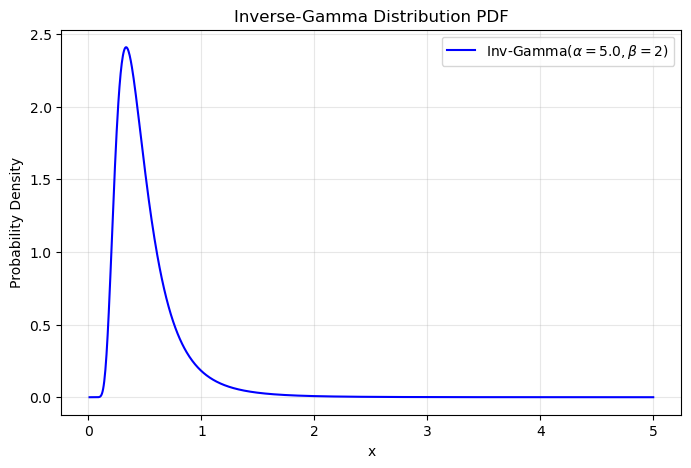

In [525]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, gamma

# 1. Define parameters
alpha = 5.0   # Shape parameter (often denoted as 'a')
beta = 2   # Scale parameter (often denoted as 'scale')

# 2. Define the x-axis range
# Note: Start slightly above 0 to avoid division by zero errors
x = np.linspace(0.01, 5, 1000)

# 3. Calculate the PDF
# scipy.stats.invgamma uses 'a' for shape and 'scale' for scale (beta)
y = invgamma.pdf(x, a=alpha, scale=beta)

# 4. Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Inv-Gamma($\\alpha={alpha}, \\beta={beta}$)', color='blue')
plt.title('Inverse-Gamma Distribution PDF')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

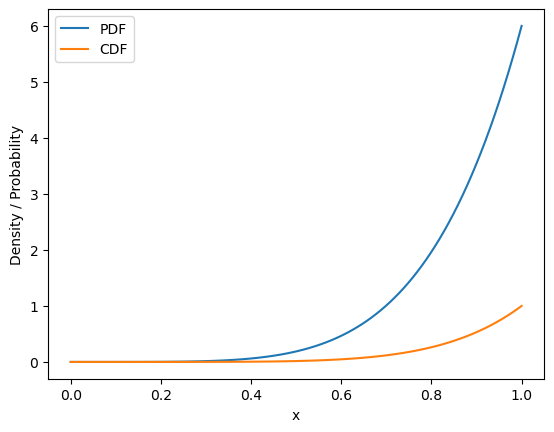

In [455]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

# Tham số
a, b = 6, 1

# Tạo grid x
x = np.linspace(0, 1, 100)

# PDF
pdf = beta.pdf(x, a, b)

# CDF
cdf = beta.cdf(x, a, b)

# Plot PDF
plt.plot(x, pdf, label='PDF')
plt.plot(x, cdf, label='CDF')
plt.xlabel('x')
plt.ylabel('Density / Probability')
plt.legend()
plt.show()


## Label Assignment

We might consider to add in the model the spatial effect

In [477]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;           
  real alpha;         
  vector[P1] beta1;
  ordered[K] beta2_col1;
  vector[K] beta2_col2;
  vector<lower=1e-6>[K] sigma2; 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  matrix[K, P2] beta2;
  beta2[:, 1] = beta2_col1; 
  beta2[:, 2] = beta2_col2; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.5/K, K)); 


  tau2  ~ gamma(3,2);
  rho   ~ uniform(0,1);
  sigma2 ~ inv_gamma(3,2);
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);

  for (k in 1:K)
    beta2[k] ~ normal(0, 2);

  phi ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;

    for (k in 1:K) {
      real mu_ik;

      mu_ik =
        alpha
        + dot_product(row(X_star, i), beta1)
        + dot_product(row(E_star, i), beta2[k])
        + phi[i];

      lps[k] =
        log(pi[k]) +
        normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2[k]));
    }

    target += log_sum_exp(lps);
  }
}


generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha
        + dot_product(row(X_star, i), beta1)
        + dot_product(row(E_star, i), beta2[k])
        + phi[i];
      lps[k] =
        log(pi[k]) +
        normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2[k]));
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [606]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1;        
  int<lower=1> P2;         
  
  vector[N] y_star;              
  matrix[N, P1] X_star;    
  matrix[N, P2] E_star;    
  matrix<lower=0, upper=1>[N, N] W;        
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;     

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  real alpha;          
  vector[P1] beta1;             
  
  vector[P2] beta2_global;     
  matrix[N, P2] phi;           
  
  vector<lower=0>[P2] tau2;      
  vector<lower=0, upper=0.95>[P2] rho; 
  
  real<lower=0> sigma2;        
}

transformed parameters {
  matrix[N, P2] beta2_local; 

  for (j in 1:P2) {
    beta2_local[:, j] = beta2_global[j] + phi[:, j];
  }
}

model {
  alpha ~ normal(0, 1);
  beta1 ~ normal(0, 1);
  beta2_global ~ normal(0, 1);

  sigma2 ~ inv_gamma(3,2);
  
  for (j in 1:P2) {
    tau2[j]  ~ gamma(3,2);
    rho[j]   ~ uniform(0,1);
    
    phi[:, j] ~ car_leroux(tau2[j], rho[j], W, D, lambda, N);
  }

  // Likelihood
  {
    vector[N] mu;
    mu = alpha 
         + X_star * beta1 
         + rows_dot_product(E_star, beta2_local); 
    
    y_star ~ normal(mu, sqrt(sigma2));
  }
}
"""

In [570]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {         
  real alpha;         
  vector[P1] beta1;
  vector[P2] beta2;
  real<lower=1e-6> sigma2; 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}


model {
  tau2  ~ gamma(3,2);
  rho   ~ uniform(0,1);
  sigma2 ~ inv_gamma(3,2);
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);
  beta2 ~ normal(0,1);

  phi ~ car_leroux(tau2, rho, W, D, lambda, N);
  
  
  for (i in 1:N) {
    real mu;
    
    mu = alpha + dot_product(row(X_star, i), beta1) + dot_product(row(E_star, i), beta2);
       
    y_star[i] ~ normal(mu, sqrt(sigma2));
  }
}


"""

In [588]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {         
  real alpha;         
  vector[P1] beta1;
  real beta2;
  real<lower=1e-6> sigma2; 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] beta2_local;
  beta2_local = beta2 + phi;
}

model {
  tau2  ~ gamma(3,2);
  rho   ~ uniform(0,1);
  sigma2 ~ inv_gamma(3,2);
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);
  beta2 ~ normal(0,1);

  phi ~ car_leroux(tau2, rho, W, D, lambda, N);
  

  for (i in 1:N) {
    real mu;
    
    mu = alpha + dot_product(row(X_star, i), beta1) + beta2_local[i] * E_star[i,1] + phi[i];
       
    y_star[i] ~ normal(mu, sqrt(sigma2));
  }
}


"""

In [708]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;
  vector[K] alpha;         
  vector[P1] beta1;
  matrix[K,P2] beta2;
  real<lower=1e-6> sigma2; 
  vector<lower=0>[P2] tau2;                  // CAR precision
  matrix[N,P2] phi;                        // Spatial random effects
  vector<lower=0, upper=0.95>[P2] rho;      // Leroux dependence parameter
}

model {
  pi ~ dirichlet(rep_vector(1.0, K));
  sigma2 ~ inv_gamma(3,2);

  for (j in 1:P2) {
    tau2[j]  ~ gamma(3,2);
    rho[j]   ~ uniform(0,1);
  }
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);

  for (k in 1:K) {
    beta2[k,:] ~ normal(0,1);
  }

  for (j in 1:P2) {
    phi[:,j] ~ car_leroux(tau2[j], rho[j], W, D, lambda, N);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps; 

    for (k in 1:K) {
      real mu_ik;
      
      vector[P2] coeff_local = (beta2[k,:] + phi[i, :])';
      
      mu_ik = alpha[k]
            + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), coeff_local);

      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }
    
    target += log_sum_exp(lps);
  }
}


generated quantities {
  array[N] int z;
  array[N, K] vector[P2] coeff_local_raw;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      vector[P2] effect = (beta2[k,:] + phi[i, :])';
      
      coeff_local_raw[i, k] = effect;
      
      real mu_ik = alpha[k]
        + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), effect);
        
      lps[k] =
        log(pi[k]) +
        normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}


"""

In [ ]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;
  vector[K] alpha;         
  vector[P1] beta1;
  matrix[K,P2] beta2;
  real<lower=1e-6> sigma2; 
  vector<lower=0>[P2] tau2;                  // CAR precision
  vector[N] phi;                        // Spatial random effects
  vector<lower=0, upper=0.95>[P2] rho;      // Leroux dependence parameter
}

model {
  pi ~ dirichlet(rep_vector(1.0, K));
  sigma2 ~ inv_gamma(3,2);

  tau2  ~ gamma(3,2);
  rho   ~ uniform(0,1);
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);

  for (k in 1:K) {
    beta2[k,:] ~ normal(0,1);
  }

  phi ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    vector[K] lps; 

    for (k in 1:K) {
      real mu_ik;
      
      vector[P2] coeff_local = (beta2[k,:])';
      
      mu_ik = alpha[k]
            + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), coeff_local)
            + phi[i];

      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }
    
    target += log_sum_exp(lps);
  }
}


generated quantities {
  array[N] int z;
  array[N, K] vector[P2] coeff_local_raw;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      vector[P2] effect = (beta2[k,:])';
      
      coeff_local_raw[i, k] = effect;
      
      real mu_ik = alpha[k]
        + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), effect) + phi[i];
        
      lps[k] =
        log(pi[k]) +
        normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}


"""

In [737]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        
    Wphi = W * phi;        

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P1; 
  int<lower=1> P2; 
  int<lower=1> K;          // Truncation level
  vector[N] y_star;              
  matrix[N, P1] X_star;  
  matrix[N, P2] E_star;  
  matrix<lower=0, upper=1>[N, N] W;        
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);       // eigenvalues
}

parameters {
  vector<lower=0, upper=1>[K-1] v;  // Stick-breaking proportions
  real<lower=0> alpha_dp;           // Concentration parameter

  vector[K] alpha;          
  vector[P1] beta1;
  matrix[K,P2] beta2;
  real<lower=1e-6> sigma2; 

  real<lower=0> tau2;                  
  vector[N] phi;                        
  real<lower=0, upper=0.95> rho;      
}

transformed parameters {
  simplex[K] pi;
  {
    real remaining = 1.0;
    for (k in 1:(K-1)) {
      pi[k] = v[k] * remaining;
      remaining = remaining * (1 - v[k]);
    }
    pi[K] = remaining; 
  }
}

model {
  alpha_dp ~ gamma(3, 2); 
  v ~ beta(1, alpha_dp);

  sigma2 ~ inv_gamma(3,2);
  tau2   ~ gamma(3,2);
  rho    ~ uniform(0,1);
  
  alpha ~ normal(0,1);
  beta1 ~ normal(0,1);

  for (k in 1:K) {
    beta2[k,:] ~ normal(0,1);
  }

  phi ~ car_leroux(tau2, rho, W, D, lambda, N);

  for (i in 1:N) {
    vector[K] lps; 

    for (k in 1:K) {
      real mu_ik;
      
      vector[P2] coeff_local = (beta2[k,:])';
      
      mu_ik = alpha[k]
            + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), coeff_local)
            + phi[i];

      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }
    
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;
  array[N, K] vector[P2] coeff_local_raw;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      vector[P2] effect = (beta2[k,:])';
      
      coeff_local_raw[i, k] = effect;
      
      real mu_ik = alpha[k]
        + dot_product(row(X_star, i), beta1) 
            + dot_product(row(E_star, i), effect) + phi[i];
        
      lps[k] =
        log(pi[k]) +
        normal_lpdf(y_star[i] | mu_ik, sqrt(sigma2));
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}
"""

In [738]:
with open("normal_mixture_car.stan", "w") as f:
    f.write(mix_model)

In [739]:
mix_stan = CmdStanModel(stan_file="normal_mixture_car.stan")

11:47:18 - cmdstanpy - INFO - compiling stan file E:\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_car.stan to exe file E:\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_car.exe
11:49:34 - cmdstanpy - INFO - compiled model executable: E:\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_car.exe


In [757]:
data = {
    "N": int(N),
    "P1": int(P1),
    "P2": int(P2),
    "K": 3,
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "E_star": E_star.astype(float),
    "W": W,
}


In [758]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=10000,
    iter_sampling=5000
)

12:38:09 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/15000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/15000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/15000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/15000 [00:00<?, ?it/s, (Warmup)]

12:42:57 - cmdstanpy - INFO - CmdStan done processing.
12:42:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'normal_mixture_car.stan', line 86, column 2 to column 22)
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'normal_mixture_car.stan', line 86, column 2 to column 22)
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'normal_mixture_car.stan', line 86, column 2 to column 22)
Consider re-running with show_console=True if the above output is unclear!


12:42:58 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 39 divergent transitions (0.8%)
	Chain 2 had 33 divergent transitions (0.7%)
	Chain 3 had 34 divergent transitions (0.7%)
	Chain 4 had 27 divergent transitions (0.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [759]:
# Cài đặt để hiện TẤT CẢ các dòng
pd.set_option('display.max_rows', None)

# Nếu bảng có nhiều cột bị ẩn, bạn có thể chỉnh thêm:
pd.set_option('display.max_columns', None)

fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,84.761800,0.188387,11.660100,11.473200,6.483180e+01,85.343500,103.052000,3841.740,7099.430,12.29000,1.00128
v[1],0.992411,0.000271,0.017820,0.003463,9.697030e-01,0.997642,1.000000,5878.810,3550.820,18.80670,1.00029
v[2],0.694282,0.002505,0.305216,0.291875,1.018610e-01,0.798091,0.999981,7411.280,3450.650,23.70910,1.00050
alpha_dp,0.489722,0.003324,0.293828,0.256704,1.327510e-01,0.431092,1.046900,5900.080,5761.850,18.87470,1.00053
alpha[1],0.054622,0.005050,0.117876,0.111194,-1.355890e-01,0.053092,0.250694,555.625,944.849,1.77748,1.01004
alpha[2],0.000814,0.007874,0.970918,0.949901,-1.649860e+00,0.018232,1.593110,15265.100,12062.600,48.83390,1.00026
alpha[3],0.006613,0.007758,0.986906,0.974262,-1.621220e+00,0.016293,1.639260,16197.000,13872.700,51.81520,1.00045
beta1[1],-0.127773,0.001222,0.080095,0.078967,-2.607470e-01,-0.127251,0.003874,4305.600,7310.930,13.77390,1.00067
beta1[2],-0.081232,0.000610,0.043709,0.043486,-1.524860e-01,-0.081322,-0.008966,5171.870,10301.300,16.54510,1.00064
beta1[3],-0.053026,0.000908,0.062812,0.062879,-1.567380e-01,-0.053022,0.050544,4801.350,8529.180,15.35980,1.00078


Đang tìm số cụm tối ưu...
-> Số cụm (nhóm) tự nhiên nhất là: 2


C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

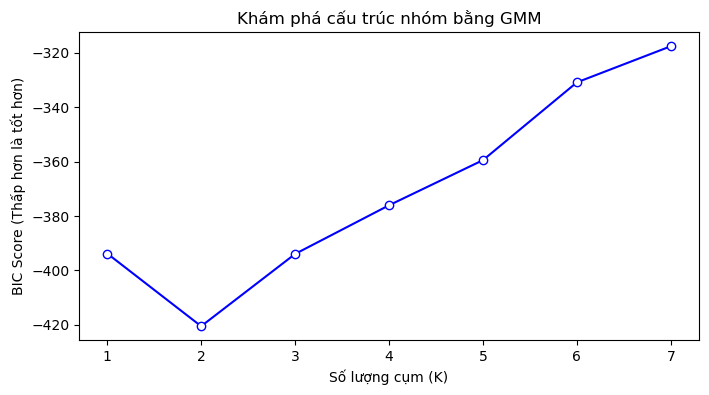

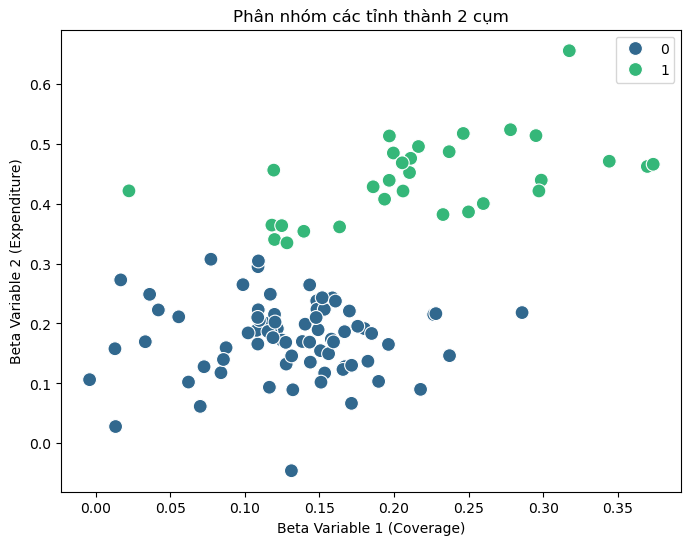

In [612]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

# --------------------------
# BƯỚC 1: TRÍCH XUẤT DỮ LIỆU
# --------------------------
# Giả sử 'fit' là kết quả chạy CmdStanPy
# beta_samples shape: (Số mẫu, Số tỉnh, Số biến SVC)
beta_samples = fit.stan_variable('beta2_local')

# Tính trung bình (Posterior Mean) cho từng tỉnh
# Kết quả beta_means shape: (Số tỉnh, Số biến SVC)
beta_means = np.mean(beta_samples, axis=0)

# --------------------------
# BƯỚC 2: TÌM SỐ CỤM TỰ NHIÊN (BIC)
# --------------------------
# Nếu P2=1 (chỉ có Coverage), beta_means cần reshape
if len(beta_means.shape) == 1:
    X_cluster = beta_means.reshape(-1, 1)
else:
    X_cluster = beta_means

n_components = range(1, 8)
bics = []
models = []

print("Đang tìm số cụm tối ưu...")
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_cluster)
    bics.append(gmm.bic(X_cluster))
    models.append(gmm)

# Chọn K có BIC thấp nhất
best_idx = np.argmin(bics)
best_k = n_components[best_idx]
best_model = models[best_idx]

print(f"-> Số cụm (nhóm) tự nhiên nhất là: {best_k}")

# Vẽ biểu đồ BIC
plt.figure(figsize=(8, 4))
plt.plot(n_components, bics, 'bo-', markerfacecolor='white')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('BIC Score (Thấp hơn là tốt hơn)')
plt.title('Khám phá cấu trúc nhóm bằng GMM')
plt.show()

# --------------------------
# BƯỚC 3: GÁN NHÃN VÀ VẼ KẾT QUẢ
# --------------------------
# Dự đoán nhãn cụm cho từng tỉnh
labels = best_model.predict(X_cluster)

# Gán vào DataFrame (giả sử bạn có gdf chứa bản đồ)
# gdf['beta_coverage'] = beta_means[:, 0]
# gdf['cluster_id'] = labels

# Vẽ biểu đồ phân tán (Nếu có 2 biến SVC)
if X_cluster.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_cluster[:, 0], y=X_cluster[:, 1], hue=labels, palette='viridis', s=100)
    plt.xlabel('Beta Variable 1 (Coverage)')
    plt.ylabel('Beta Variable 2 (Expenditure)')
    plt.title(f'Phân nhóm các tỉnh thành {best_k} cụm')
    plt.show()
else:
    # Nếu chỉ có 1 biến, vẽ Histogram tô màu
    plt.figure(figsize=(8, 6))
    for i in range(best_k):
        subset = X_cluster[labels == i]
        sns.kdeplot(subset, fill=True, label=f'Cluster {i}')
    plt.xlabel('Beta Coverage')
    plt.legend()
    plt.show()

In [617]:
gdf['beta_coverage'] = beta_means[:, 0]
gdf['per_capita_user_contribution'] = beta_means[:, 1]
gdf['cluster_id'] = labels

In [619]:
cluster_stats = gdf.groupby('cluster_id')['beta_coverage'].describe()
print("Thống kê mô tả Beta theo cụm:")
print(cluster_stats)

Thống kê mô tả Beta theo cụm:
            count      mean       std       min       25%       50%       75%  \
cluster_id                                                                      
0            76.0  0.129359  0.053503 -0.004023  0.108714  0.131328  0.158917   
1            31.0  0.218020  0.080893  0.022357  0.174768  0.210403  0.268956   

                 max  
cluster_id            
0           0.285823  
1           0.373720  


In [620]:
cluster_stats = gdf.groupby('cluster_id')['per_capita_user_contribution'].describe()
print("Thống kê mô tả Beta theo cụm:")
print(cluster_stats)

Thống kê mô tả Beta theo cụm:
            count      mean       std       min       25%       50%       75%  \
cluster_id                                                                      
0            76.0  0.175628  0.062356 -0.046103  0.136480  0.183686  0.215468   
1            31.0  0.442194  0.067923  0.334622  0.393317  0.439442  0.480363   

                 max  
cluster_id            
0           0.307262  
1           0.655664  


In [565]:
import numpy as np

# 1. Lấy toàn bộ mẫu (kết quả là ma trận: Số mẫu x Số tỉnh)
# Ví dụ: (4000 mẫu, 107 tỉnh)
beta_samples = fit.stan_variable('beta2_local')

# 2. Tính trung bình dọc theo trục dọc (axis=0) để ra 1 giá trị cho mỗi tỉnh
beta_means = np.mean(beta_samples, axis=0)

# Kiểm tra kích thước (nếu là 107 tỉnh thì shape phải là (107,))
print(beta_means.shape)

(107,)


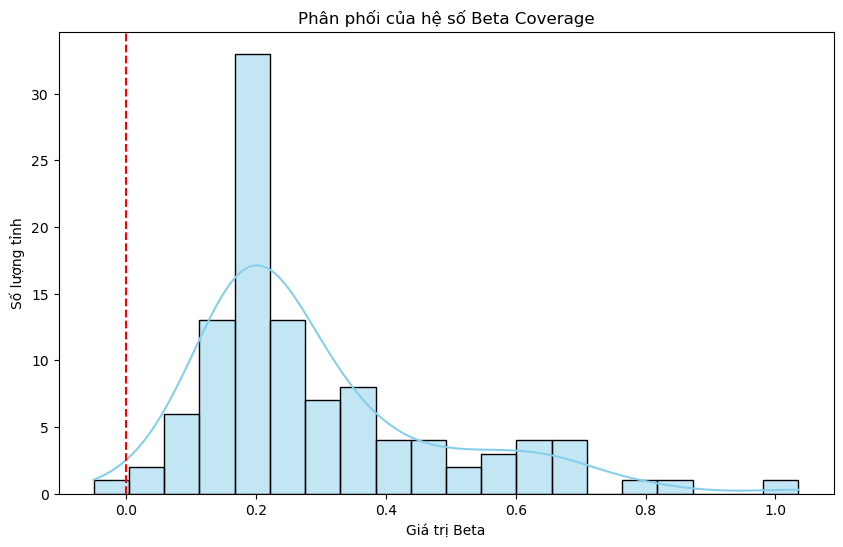

In [568]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy dữ liệu beta trung bình
beta_means = fit.stan_variable('beta2_local').mean(axis=0)

plt.figure(figsize=(10, 6))
sns.histplot(beta_means, kde=True, bins=20, color='skyblue')
plt.title("Phân phối của hệ số Beta Coverage")
plt.xlabel("Giá trị Beta")
plt.ylabel("Số lượng tỉnh")
plt.axvline(0, color='red', linestyle='--') # Đường tham chiếu 0
plt.show()

In [760]:
fit.stan_variable('beta2')

array([[[ 0.10329329,  0.10213469],
        [-3.2016369 , -0.48652994],
        [-1.4248491 , -1.7807044 ]],

       [[ 0.11213709,  0.1026788 ],
        [-3.1174175 , -0.23169846],
        [-1.2780898 , -1.7518507 ]],

       [[ 0.12915607,  0.07648768],
        [-2.7828032 ,  0.24422228],
        [-2.4000691 , -0.59465869]],

       ...,

       [[ 0.10565621,  0.17039644],
        [-1.1861632 , -2.1474642 ],
        [ 0.28282095,  0.30133805]],

       [[ 0.09944088,  0.04748179],
        [ 1.4933091 , -1.1150098 ],
        [ 0.29798149, -0.34248014]],

       [[ 0.11931531,  0.09127468],
        [-1.0346922 , -0.01922423],
        [-1.5746995 , -0.28642863]]], shape=(20000, 3, 2))

In [761]:
z_draws = fit.stan_variable("z")   # shape: (n_draws, N)

In [762]:
import arviz as az
cmdstanpy_data = az.from_cmdstanpy(fit)

C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\arviz\plots\traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (877), generating only 20 plots
  warnings.warn(


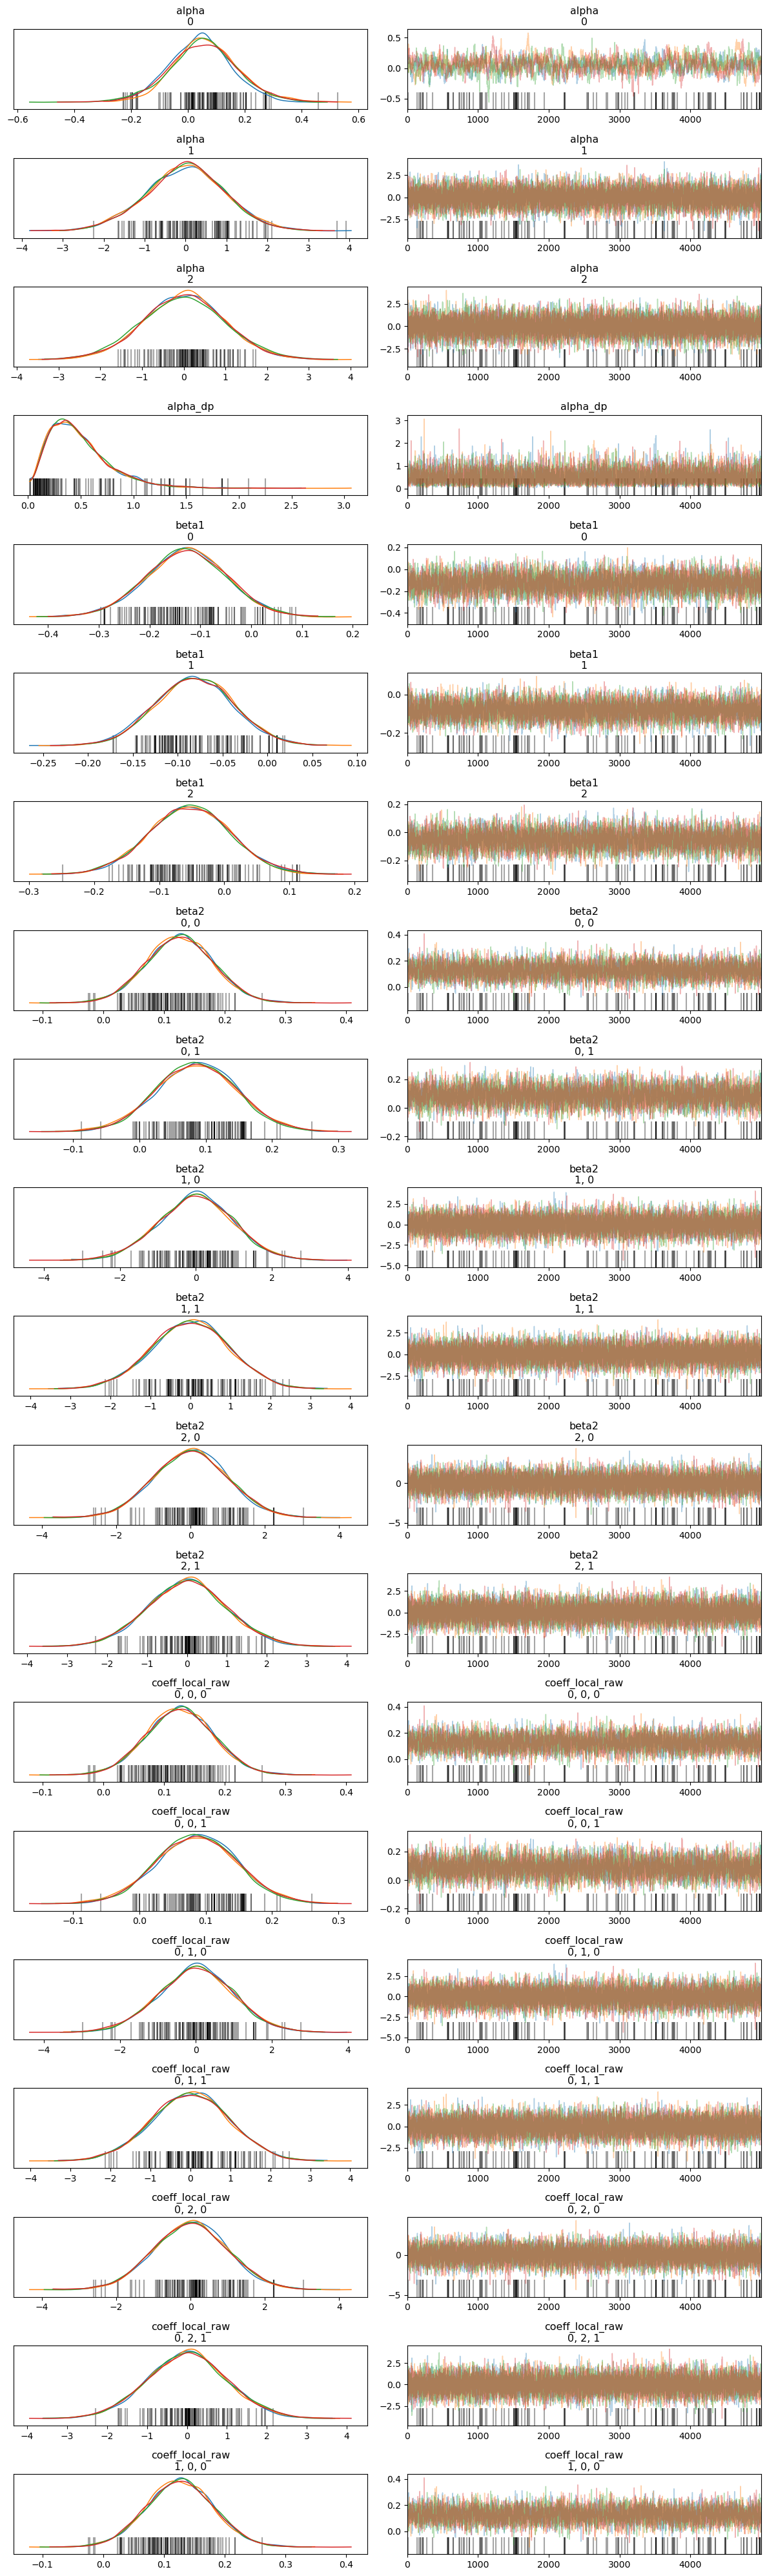

In [763]:
import matplotlib.pyplot as plt
az.plot_trace(cmdstanpy_data, compact=False)
plt.tight_layout()
plt.show()

In [764]:
## For each draw:
# - compare couples of observations
# - if they are equal (same label) increment the counter
# - normalize

# At the end psm[i, j] is the posterior probability that observations i and j belong to the same cluster

# Shape is n_draws x n_obs, and the numbers are class labels

@njit
def build_psm(posterior):
    n_draws, n_obs = posterior.shape
    psm = np.zeros((n_obs, n_obs))
    for row in posterior:
        for r_idx, i in enumerate(row):
            for c_idx, j in enumerate(row):
                if i == j:
                    psm[r_idx, c_idx] += 1
                    
    psm /= n_draws
        
    return psm

In [765]:
psm = build_psm(z_draws.astype(np.int64))

In [766]:
def order_by_hclust(psm, method="average"):
    # convert similarity -> distance
    D = 1.0 - psm
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 1.0)

    # linkage needs condensed distances
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    order = leaves_list(Z)   # permutation of 0..N-1
    return order

order = order_by_hclust(psm)
psm_sorted = psm[np.ix_(order, order)]

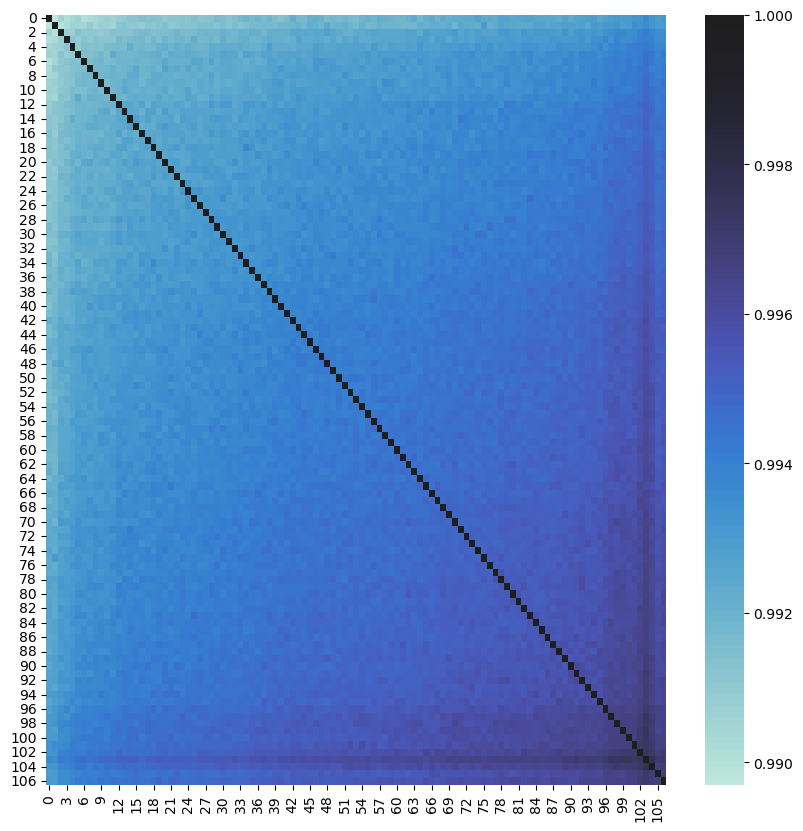

In [767]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted, center=1)
plt.show()

In [768]:
def binder_loss(psm, labels):
    # expected Binder loss from PSM (sum over i<j)
    labels = np.asarray(labels)
    A = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(psm.shape[0], k=1)
    return float(np.sum(np.abs(A[iu] - psm[iu])))

def binder_optimal_partition(psm, k_min, k_max):
    psm = np.asarray(psm, dtype=float)
    psm = 0.5 * (psm + psm.T)
    np.fill_diagonal(psm, 1.0)

    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)

    best_loss = np.inf
    best_labels = None

    for k in range(k_min, min(k_max, psm.shape[0]) + 1):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
            metric="precomputed",  
        )
        labels = model.fit_predict(dist)
        loss = binder_loss(psm, labels)
        if loss < best_loss:
            best_loss = loss
            best_labels = labels

    return best_labels, best_loss

In [769]:
labels_opt, loss_opt = binder_optimal_partition(psm, k_min=1, k_max=5)

In [770]:
labels_opt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [771]:
labels = labels_opt + 1

In [772]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


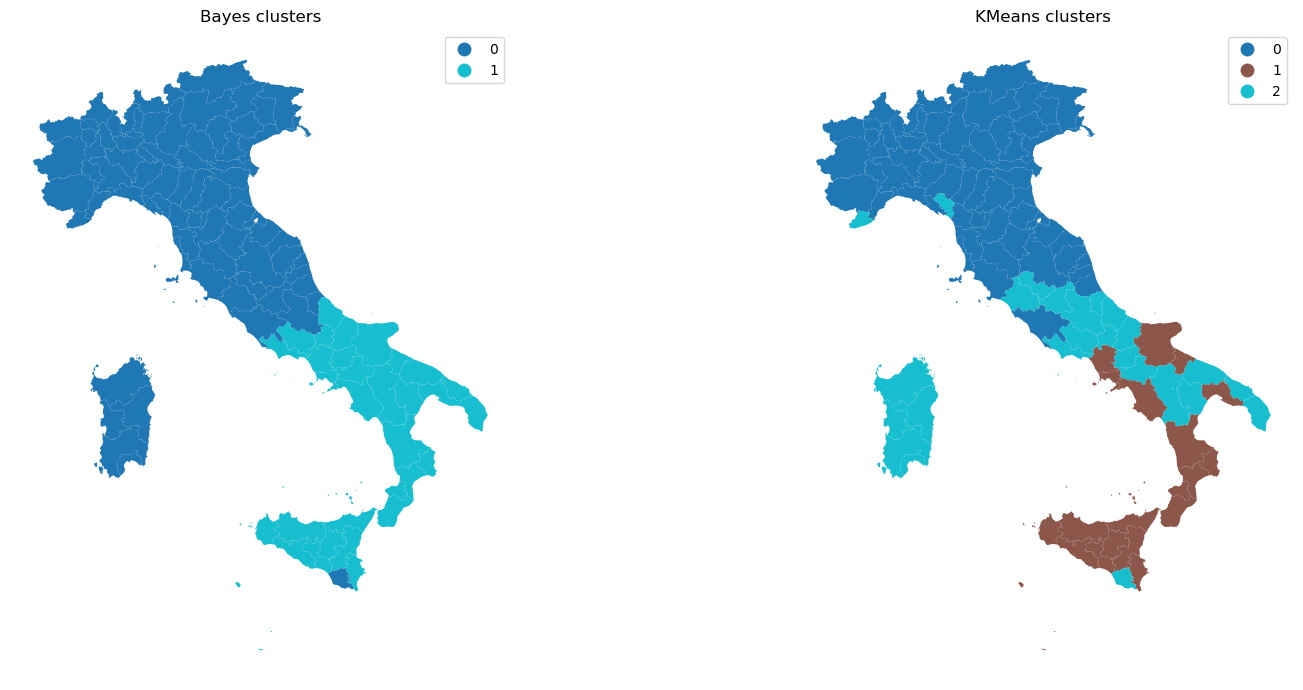

In [773]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons


kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_star.reshape(-1, 1))
gdf["cluster"] = kmeans.labels_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="cluster_id", categorical=True, legend=True, ax=ax1)
ax1.set_title("Bayes clusters")
ax1.set_axis_off()

gdf.plot(column="cluster", categorical=True, legend=True, ax=ax2)
ax2.set_title("KMeans clusters")
ax2.set_axis_off()

plt.tight_layout()
plt.show()


In [774]:
with open("labels.txt", "w") as f:
    for x in labels:
        f.write(f"{x}\n")